Praktikum D1 - Regresi dari Citra Sintetis (Prediksi Radius Lingkaran)

1. Setup & Generator Dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models
# Generator 1 sample
def make_sample(img_size=64, min_r=5, max_r=20):
  r = np.random.randint(min_r, max_r + 1)  # radius acak
  img = np.zeros((img_size, img_size), dtype=np.uint8)
  cx = np.random.randint(r, img_size - r)  # center-x
  cy = np.random.randint(r, img_size - r)  # center-y
  cv2.circle(img, (cx, cy), r, (255,), -1)  # lingkaran putih terisi
  img = (img / 255.0).astype(np.float32)
  # 3-channel biar kompatibel CNN
  img3 = np.stack([img, img, img], axis=-1)
  return img3, float(r), (cx, cy)

2. Tampilkan Contoh Gambar TANPA Label

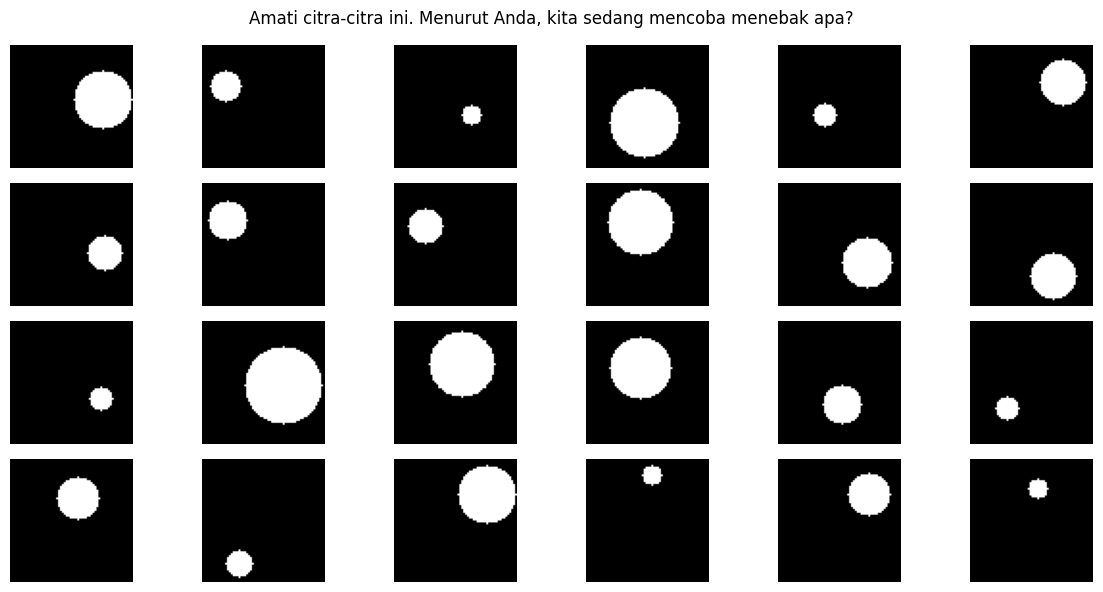

In [ ]:
# Buat 24 contoh untuk visualisasi
N_show = 24
samples = [make_sample() for _ in range(N_show)]
imgs = [s[0] for s in samples]
rads = [s[1] for s in samples]
centers = [s[2] for s in samples]
# Grid gambar tanpa label:
cols = 6
rows = N_show // cols
plt.figure(figsize=(12, 6))
for i in range(N_show):
    plt.subplot(rows, cols, i+1)
    plt.imshow(imgs[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle("Amati citra-citra ini. Menurut Anda, kita sedang mencoba menebak apa?")
plt.tight_layout()
plt.show()

3. Target yang Ingin Diprediksi

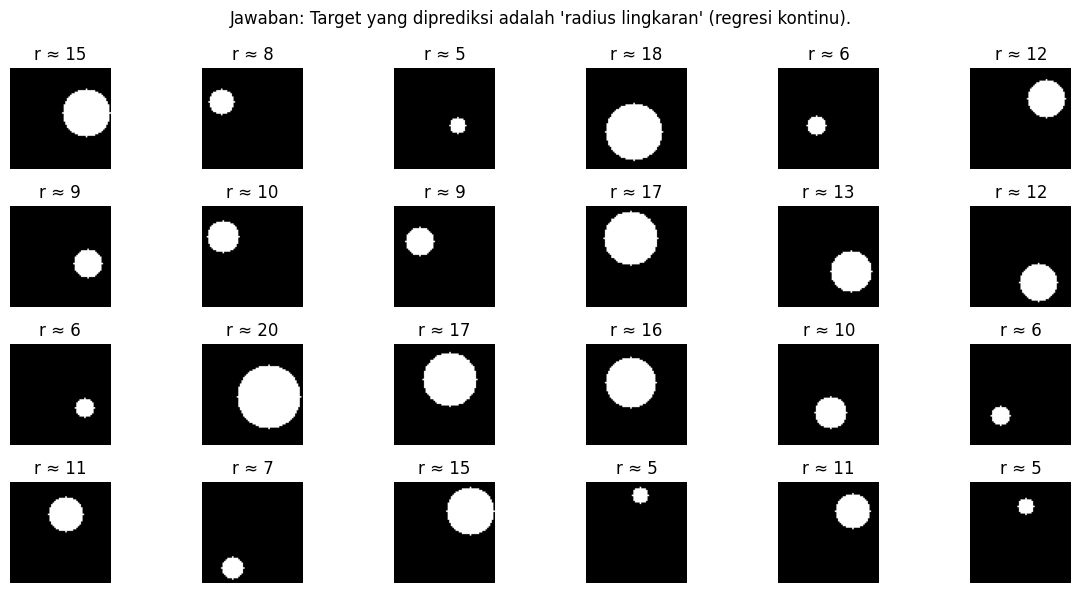

In [ ]:
# Tampilkan kembali, sekarang tampilkan radius (label) di judul tiap subplot
plt.figure(figsize=(12, 6))
for i in range(N_show):
    plt.subplot(rows, cols, i+1)
    plt.imshow(imgs[i].squeeze(), cmap='gray')
    plt.title(f"r ≈ {int(rads[i])}")
    plt.axis('off')
plt.suptitle("Jawaban: Target yang diprediksi adalah 'radius lingkaran' (regresi kontinu).")
plt.tight_layout()
plt.show()

4. Latih CNN Kecil untuk Memprediksi Radius

In [ ]:
N = 3000
X, y, C = zip(*[make_sample() for _ in range(N)])
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

# Model CNN sederhana
model = models.Sequential([
    layers.Input((64,64,3)),
    layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'), layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)  # output regresi
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(Xtr, ytr, validation_data=(Xte, yte),
                    epochs=12, batch_size=64, verbose=0)

# Evaluasi
y_pred = model.predict(Xte).ravel()
mae = mean_absolute_error(yte, y_pred)
rmse = float(np.sqrt(np.mean((yte - y_pred)**2)))
r2 = r2_score(yte, y_pred)
print(f"MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step
MAE=0.954 | RMSE=1.164 | R²=0.939


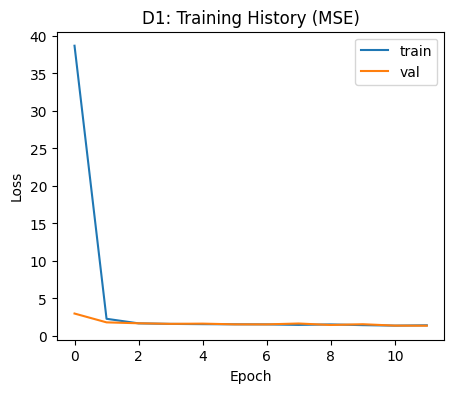

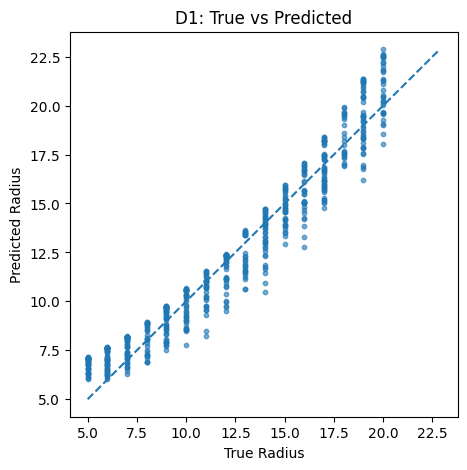

In [ ]:
# Plot loss
plt.figure(figsize=(5,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("D1: Training History (MSE)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()

# Scatter True vs Pred
plt.figure(figsize=(5,5))
plt.scatter(yte, y_pred, s=10, alpha=0.6)
lims = [min(yte.min(), y_pred.min()), max(yte.max(), y_pred.max())]
plt.plot(lims, lims, '--')
plt.xlabel("True Radius"); plt.ylabel("Predicted Radius")
plt.title("D1: True vs Predicted")
plt.show()

5. Tantangan Mini

In [ ]:
# 1: Mengubah Rentang Radius

print("Menyiapkan data Tantangan 1...")
# Bangkitkan data dengan rentang radius baru
X_t1, y_t1, _ = zip(*[make_sample(min_r=8, max_r=28) for _ in range(3000)])
X_t1 = np.array(X_t1, dtype=np.float32)
y_t1 = np.array(y_t1, dtype=np.float32)

Xtr_t1, Xte_t1, ytr_t1, yte_t1 = train_test_split(X_t1, y_t1, test_size=0.2, random_state=42)

# Buat ulang arsitektur model agar belajar dari awal
model_t1 = models.Sequential([
    layers.Input((64,64,3)),
    layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

model_t1.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_t1.fit(Xtr_t1, ytr_t1, validation_data=(Xte_t1, yte_t1), epochs=12, batch_size=64, verbose=0)

# Evaluasi
y_pred_t1 = model_t1.predict(Xte_t1).ravel()
print(f"Hasil Tantangan 1 (Radius 8-28) -> MAE: {mean_absolute_error(yte_t1, y_pred_t1):.3f} | RMSE: {float(np.sqrt(np.mean((yte_t1 - y_pred_t1)**2))):.3f} | R^2: {r2_score(yte_t1, y_pred_t1):.3f}")

Menyiapkan data Tantangan 1...
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
Hasil Tantangan 1 (Radius 8-28) -> MAE: 0.778 | RMSE: 0.971 | R^2: 0.973


Menyiapkan data Tantangan 2...
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
Hasil Tantangan 2 (Pakai Noise) -> MAE: 0.908 | RMSE: 1.141 | R^2: 0.939


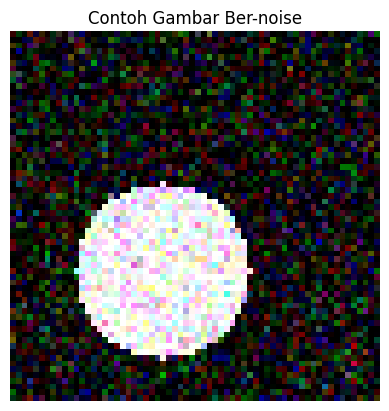

In [ ]:
# 2: Tambah Noise

print("Menyiapkan data Tantangan 2...")

# Fungsi untuk menambah noise
def make_sample_noisy():
    img3, r, center = make_sample()
    # Tambah noise acak ke gambar
    noise = np.random.normal(0, 0.2, img3.shape)
    img_noisy = np.clip(img3 + noise, 0, 1).astype(np.float32)
    return img_noisy, r, center

X_t2, y_t2, _ = zip(*[make_sample_noisy() for _ in range(3000)])
X_t2 = np.array(X_t2, dtype=np.float32)
y_t2 = np.array(y_t2, dtype=np.float32)

Xtr_t2, Xte_t2, ytr_t2, yte_t2 = train_test_split(X_t2, y_t2, test_size=0.2, random_state=42)

model_t2 = models.Sequential([
    layers.Input((64,64,3)),
    layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

model_t2.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_t2.fit(Xtr_t2, ytr_t2, validation_data=(Xte_t2, yte_t2), epochs=12, batch_size=64, verbose=0)

y_pred_t2 = model_t2.predict(Xte_t2).ravel()
print(f"Hasil Tantangan 2 (Pakai Noise) -> MAE: {mean_absolute_error(yte_t2, y_pred_t2):.3f} | RMSE: {float(np.sqrt(np.mean((yte_t2 - y_pred_t2)**2))):.3f} | R^2: {r2_score(yte_t2, y_pred_t2):.3f}")

# Coba kita intip 1 gambar ber-noise-nya
plt.imshow(Xte_t2[0].squeeze(), cmap='gray')
plt.title("Contoh Gambar Ber-noise")
plt.axis('off')
plt.show()

In [ ]:
# 3: Tugas Multi-output

print("Menyiapkan data Tantangan 3...")

# Tarik semua data: gambar, radius(r), koordinat pusat(cx, cy)
data_t3 = [make_sample() for _ in range(3000)]
X_t3 = np.array([d[0] for d in data_t3], dtype=np.float32)

# Label sekarang ada 3: [r, cx, cy]
y_t3 = np.array([[d[1], d[2][0], d[2][1]] for d in data_t3], dtype=np.float32)

Xtr_t3, Xte_t3, ytr_t3, yte_t3 = train_test_split(X_t3, y_t3, test_size=0.2, random_state=42)

model_t3 = models.Sequential([
    layers.Input((64,64,3)),
    layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3) # <--- UBAH JADI 3 NEURON (Output [r, cx, cy])
])

# Metrik MAE akan otomatis dihitung untuk ke-3 nilai secara rata-rata
model_t3.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_t3.fit(Xtr_t3, ytr_t3, validation_data=(Xte_t3, yte_t3), epochs=12, batch_size=64, verbose=0)

y_pred_t3 = model_t3.predict(Xte_t3)
mae_t3 = mean_absolute_error(yte_t3, y_pred_t3) # Rata-rata error untuk r, cx, cy

print(f"Hasil Tantangan 3 (Multi-output) -> MAE Rata-rata Gabungan: {mae_t3:.3f}")
print(f"Contoh Prediksi model: [r, cx, cy] = {y_pred_t3[0].round(1)}")
print(f"Target Sebenarnya    : [r, cx, cy] = {yte_t3[0]}")

Menyiapkan data Tantangan 3...
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
Hasil Tantangan 3 (Multi-output) -> MAE Rata-rata Gabungan: 3.536
Contoh Prediksi model: [r, cx, cy] = [12.7 45.8 29.5]
Target Sebenarnya    : [r, cx, cy] = [14. 48. 37.]


Praktikum D2 - Menebak Umur Manusia dari Foto Wajah (UTKFace)

2. Mengunggah kaggle.json ke Colab

In [ ]:
# Jalankan ini di awal notebook
from google.colab import files
files.upload()  # pilih file kaggle.json dari komputer Anda

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vannisaaldirakirani","key":"5497caacec3d8537723f353aa324a9af"}'}

In [ ]:
import os, shutil
if os.path.exists("kaggle.json"):
  os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
  shutil.copy("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
  os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
  !pip -q install kaggle
  print("✅ Kaggle API siap digunakan.")
else:
  print("kaggle.json belum ditemukan. Upload terlebih dahulu.")

✅ Kaggle API siap digunakan.


3. Mengunduh Dataset UTKFace dari Kaggle

In [ ]:
# Unduh dataset UTKFace (sekali saja)
!kaggle datasets download -d jangedoo/utkface-new -p /content -q
!unzip -q /content/utkface-new.zip -d /content/utk
print("✅ Dataset UTKFace berhasil diekstrak.")

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
✅ Dataset UTKFace berhasil diekstrak.


4. Menampilkan Contoh Gambar Dataset

Total gambar ditemukan: 23708


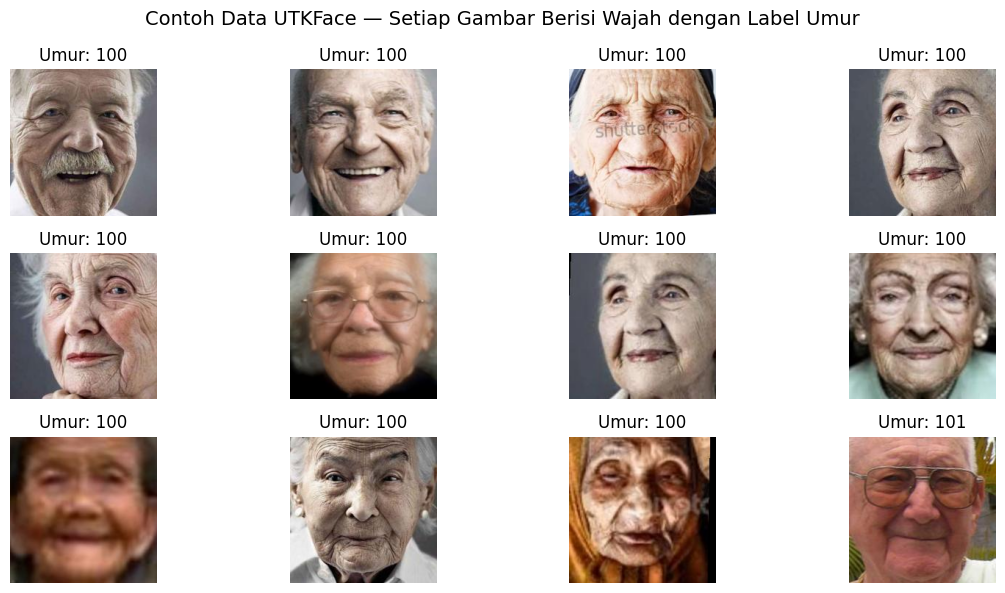

In [ ]:
import matplotlib.pyplot as plt
import os, glob
from PIL import Image

# Ambil 12 gambar acak dari dataset
files = glob.glob("/content/utk/UTKFace/*.jpg")
files = sorted(files)
print(f"Total gambar ditemukan: {len(files)}")

plt.figure(figsize=(12, 6))
for i, f in enumerate(files[:12]):
    # Ambil umur dari nama file
    age = int(os.path.basename(f).split("_")[0])
    img = Image.open(f)
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Umur: {age}")
    plt.axis("off")
plt.suptitle("Contoh Data UTKFace — Setiap Gambar Berisi Wajah dengan Label Umur", fontsize=14)
plt.tight_layout()
plt.show()

5.  Siapkan Dataset untuk Model

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

def parse_age_from_name(fp):
    return int(os.path.basename(fp).split('_')[0])

ages = np.array([parse_age_from_name(f) for f in files], dtype=np.float32)
train_files, test_files, y_train, y_test = train_test_split(
    files, ages, test_size=0.2, random_state=42
)

IMG_SIZE = 160
def load_img(fp, label):
    img = tf.io.read_file(fp)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img / 255.0, label

train_ds = tf.data.Dataset.from_tensor_slices((train_files,
y_train)).map(load_img).batch(64)
test_ds = tf.data.Dataset.from_tensor_slices((test_files,
y_test)).map(load_img).batch(64)

print("✅ Dataset siap dilatih.")

✅ Dataset siap dilatih.


6. Membangun Model dengan Transfer Learning

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Gunakan GPU jika tersedia
print("Hardware:", "GPU" if tf.config.list_physical_devices('GPU') else
"CPU")

# Buat arsitektur model
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights='imagenet'
)
base_model.trainable = False  # tahap awal: freeze backbone

# Tambahkan head regresi
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1)(x)  # output tunggal: umur
model = tf.keras.Model(inputs, outputs)

# Kompilasi model
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='mse', metrics=['mae'])

model.summary()

Hardware: CPU
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

7. Melatih Model (Tahap 1 – Frozen)

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 575s 2s/step - loss: 236.9384 - mae: 11.4434 - val_loss: 159.9890 - val_mae: 9.5919 - learning_rate: 0.0010
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 559s 2s/step - loss: 153.8059 - mae: 9.2504 - val_loss: 149.4824 - val_mae: 9.2387 - learning_rate: 0.0010
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 562s 2s/step - loss: 144.3552 - mae: 8.8884 - val_loss: 146.4061 - val_mae: 9.1444 - learning_rate: 0.0010
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 562s 2s/step - loss: 140.5416 - mae: 8.7733 - val_loss: 140.9904 - val_mae: 8.8696 - learning_rate: 0.0010
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 561s 2s/step - loss: 137.3356 - mae: 8.6420 - val_loss: 138.3964 - val_mae: 8.7301 - learning_rate: 0.0010
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 516s 2s/step - loss: 134.0344 - mae: 8.5081 - val_loss: 137.4894 - val_mae: 8.7100 - learning_rate: 0.0010
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 561s 2s/step - loss: 134.8985 - mae: 8.5376 - val_loss: 138.6183 - val_mae: 8

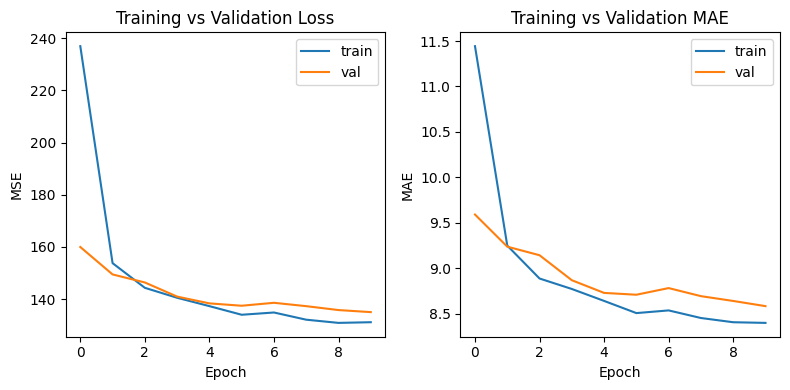

In [ ]:
# Callback untuk pelatihan yang lebih stabil
cb = [ tf.keras.callbacks.EarlyStopping(patience=3,
      restore_best_weights=True, monitor='val_loss'),
       tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, min_lr=1e5,
        monitor='val_loss')]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=cb,
    verbose=1
)

# Visualisasi perubahan loss dan MAE selama pelatihan:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='val')
plt.xlabel('Epoch'); plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.tight_layout()
plt.show()

8. Fine-tuning Backbone (Tahap 2)

Epoch 1/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 732s 2s/step - loss: 145.5895 - mae: 8.8571 - val_loss: 137.0531 - val_mae: 8.5634 - learning_rate: 1.0000e-04
Epoch 2/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 680s 2s/step - loss: 71.2044 - mae: 6.2914 - val_loss: 114.4121 - val_mae: 7.8604 - learning_rate: 1.0000e-04
Epoch 3/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 718s 2s/step - loss: 47.9522 - mae: 5.1895 - val_loss: 108.3043 - val_mae: 7.5739 - learning_rate: 1.0000e-04
Epoch 4/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 713s 2s/step - loss: 35.1250 - mae: 4.4789 - val_loss: 107.3778 - val_mae: 7.5368 - learning_rate: 1.0000e-04
Epoch 5/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 677s 2s/step - loss: 28.0972 - mae: 3.9964 - val_loss: 103.8702 - val_mae: 7.4954 - learning_rate: 1.0000e-04


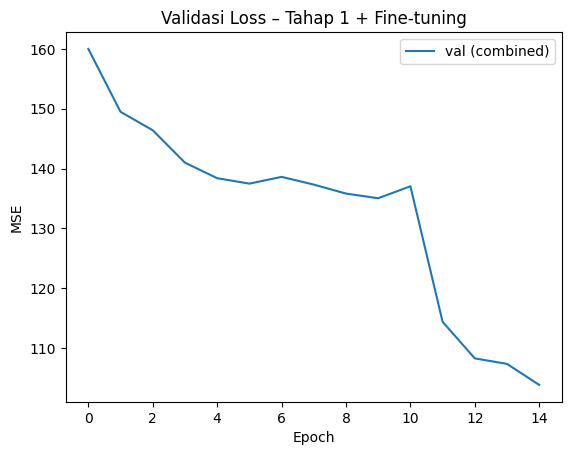

In [ ]:
# Aktifkan kembali sebagian layer terakhir untuk fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
  layer.trainable = False  # beku sebagian besar layer

# Recompile dengan learning rate lebih kecil
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='mse', metrics=['mae'])

history_ft = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5,
    callbacks=cb,
    verbose=1
)

# Visualisasi gabungan training dan fine-tuning:
plt.plot(history.history['val_loss'] + history_ft.history['val_loss'],
label='val (combined)')
plt.title("Validasi Loss – Tahap 1 + Fine-tuning")
plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.legend(); plt.show()

9. Evaluasi Akhir (MAE, RMSE, R²)

MAE  = 7.50 tahun
RMSE = 10.19 tahun
R²   = 0.738


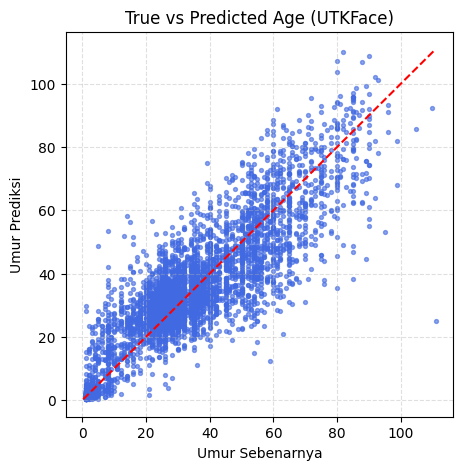

In [ ]:
from math import sqrt

y_pred = np.concatenate([model.predict(batch[0], verbose=0).ravel() for
batch in test_ds])
mae  = mean_absolute_error(y_test, y_pred)
rmse = sqrt(np.mean((y_test - y_pred)**2))
r2   = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.2f} tahun")
print(f"RMSE = {rmse:.2f} tahun")
print(f"R²   = {r2:.3f}")

# Plot “umur sebenarnya vs umur prediksi”:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, s=8, alpha=0.6, color='royalblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, '--', color='red')
plt.xlabel("Umur Sebenarnya")
plt.ylabel("Umur Prediksi")
plt.title("True vs Predicted Age (UTKFace)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

10.  Melihat Contoh Prediksi Nyata

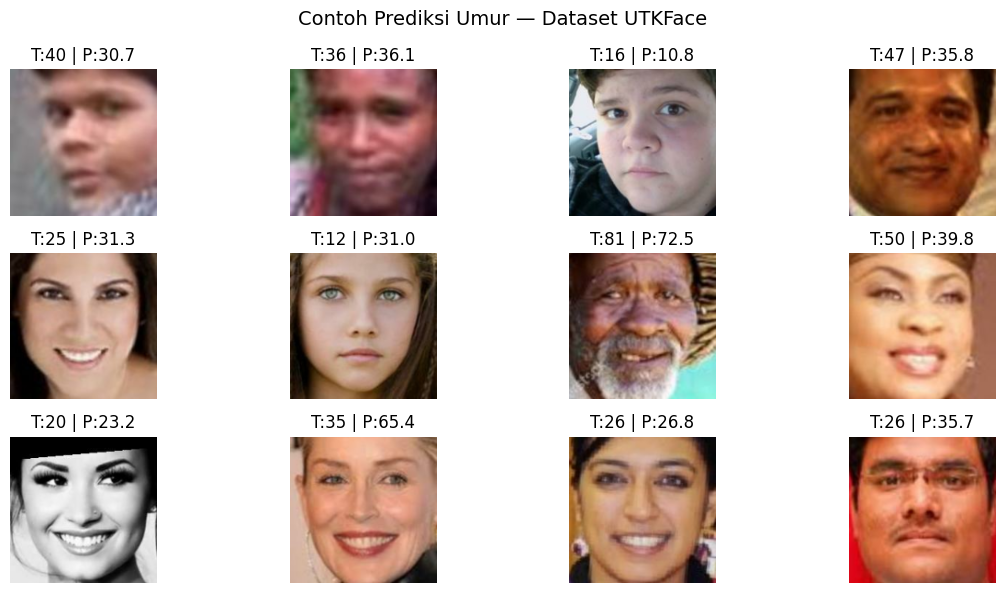

In [ ]:
import random
sample_paths = random.sample(test_files, 12)

plt.figure(figsize=(12,6))
for i, path in enumerate(sample_paths):
  img = tf.io.read_file(path)
  img = tf.image.decode_jpeg(img, channels=3)
  img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))/255.0
  true_age = int(os.path.basename(path).split('_')[0])
  pred_age = model.predict(tf.expand_dims(img, 0), verbose=0).ravel()[0]
  plt.subplot(3,4,i+1)
  plt.imshow(img.numpy())
  plt.title(f"T:{true_age} | P:{pred_age:.1f}")
  plt.axis('off')
plt.suptitle("Contoh Prediksi Umur — Dataset UTKFace", fontsize=14)
plt.tight_layout()
plt.show()

11. Tantangan Mini

In [ ]:
# 1: Data Augmentation Ekstra

def load_img_aug(fp, label):
    img = tf.io.read_file(fp)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    # Tambahkan augmentasi
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.clip_by_value(img, 0.0, 255.0)

    return img / 255.0, label

train_ds_aug = tf.data.Dataset.from_tensor_slices((train_files, y_train)).map(load_img_aug).batch(64)
print("Dataset dengan augmentasi siap! Kamu bisa melatih ulang model menggunakan `train_ds_aug` untuk melihat perubahannya pada nilai MAE.")

Dataset dengan augmentasi siap! Kamu bisa melatih ulang model menggunakan `train_ds_aug` untuk melihat perubahannya pada nilai MAE.


In [ ]:
# 2: Menubah Learning Rate Schedule

model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-3),
              loss='mse', metrics=['mae'])

print("Optimizer telah diubah ke RMSprop.")
print("Silakan jalankan ulang perintah `model.fit(...)` untuk membandingkan stabilitas pelatihannya.")

Optimizer telah diubah ke RMSprop.
Silakan jalankan ulang perintah `model.fit(...)` untuk membandingkan stabilitas pelatihannya.


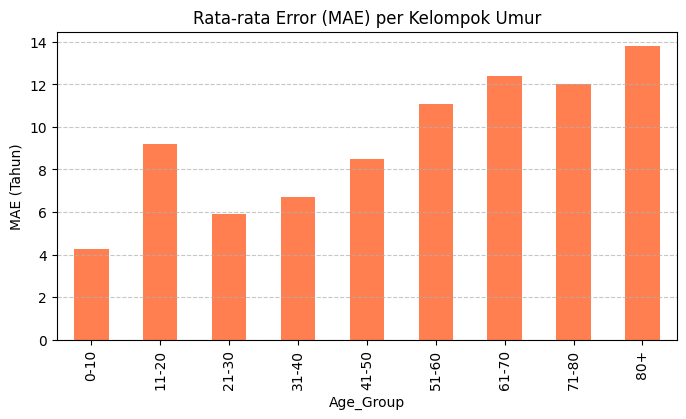

In [ ]:
# 3: Memisah Dataser Umur per Kelompok

import pandas as pd

# Pastikan y_test dan y_pred sudah tersedia dari Langkah 9
df_eval = pd.DataFrame({'True_Age': y_test, 'Pred_Age': y_pred})
df_eval['Error'] = abs(df_eval['True_Age'] - df_eval['Pred_Age'])

# Buat keranjang/kelompok umur
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 120]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '80+']
df_eval['Age_Group'] = pd.cut(df_eval['True_Age'], bins=bins, labels=labels, right=True)

mae_per_group = df_eval.groupby('Age_Group', observed=False)['Error'].mean()

# Visualisasikan
mae_per_group.plot(kind='bar', figsize=(8,4), color='coral')
plt.title("Rata-rata Error (MAE) per Kelompok Umur")
plt.ylabel("MAE (Tahun)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Silakan upload foto wajahmu (format jpg/jpeg/png):


Saving image.jpeg to image.jpeg


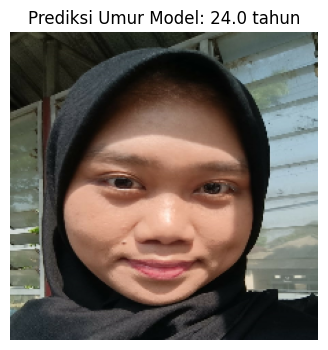

In [ ]:
# 4: Uji Model

from google.colab import files

print("Silakan upload foto wajahmu (format jpg/jpeg/png):")
uploaded = files.upload()

for fn in uploaded.keys():
    path = '/content/' + fn
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

    # Prediksi menggunakan model
    pred_age = model.predict(tf.expand_dims(img, 0), verbose=0).ravel()[0]

    # Tampilkan hasil
    plt.figure(figsize=(4,4))
    plt.imshow(img.numpy())
    plt.title(f"Prediksi Umur Model: {pred_age:.1f} tahun")
    plt.axis('off')
    plt.show()

Praktikum D3 — Menilai “Kepopuleran Hewan Peliharaan” dari Foto

In [ ]:
!rm kaggle*.json

1. Menyiapkan Kaggle API

In [ ]:
from google.colab import files
files.upload()  # pilih kaggle.json dari komputer Anda
import os, shutil
if os.path.exists("kaggle.json"):
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    shutil.copy("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
    !pip -q install kaggle
    print("✅ Kaggle API siap digunakan.")
else:
    print("    kaggle.json belum ditemukan. Upload terlebih dahulu.")

Saving kaggle.json to kaggle.json
✅ Kaggle API siap digunakan.


2. Mengunduh dan Mengekstrak Dataset

In [ ]:
# Unduh dataset Pawpularity (sekitar 800MB)
!kaggle competitions download -c petfinder-pawpularity-score -p /content -q
!unzip -q /content/petfinder-pawpularity-score.zip -d /content/paw
print("✅ Dataset Pawpularity berhasil diekstrak.")

✅ Dataset Pawpularity berhasil diekstrak.


3. Melihat Contoh Data

                                 Id  Subject Focus  Eyes  Face  Near  Action  \
0  0007de18844b0dbbb5e1f607da0606e0              0     1     1     1       0   
1  0009c66b9439883ba2750fb825e1d7db              0     1     1     0       0   
2  0013fd999caf9a3efe1352ca1b0d937e              0     1     1     1       0   
3  0018df346ac9c1d8413cfcc888ca8246              0     1     1     1       0   
4  001dc955e10590d3ca4673f034feeef2              0     0     0     1       0   

   Accessory  Group  Collage  Human  Occlusion  Info  Blur  Pawpularity  \
0          0      1        0      0          0     0     0           63   
1          0      0        0      0          0     0     0           42   
2          0      0        0      1          1     0     0           28   
3          0      0        0      0          0     0     0           15   
4          0      1        0      0          0     0     0           72   

                                                path  
0  /content/p

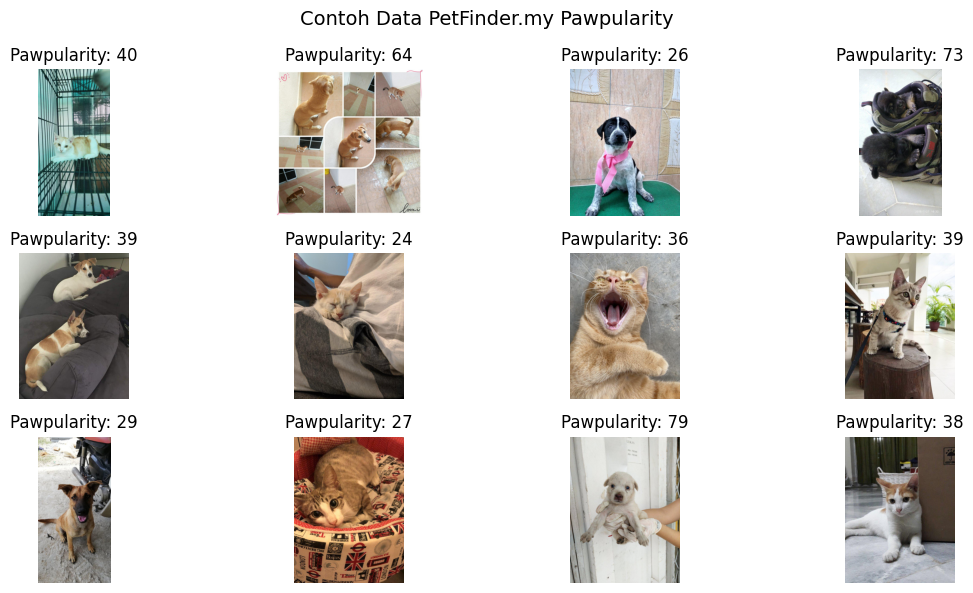

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

# Muat CSV
df = pd.read_csv('/content/paw/train.csv')
df['path'] = df['Id'].apply(lambda x: f"/content/paw/train/{x}.jpg")
print(df.head())

# Tampilkan 12 contoh gambar
plt.figure(figsize=(12, 6))
for i, row in enumerate(df.sample(12, random_state=42).itertuples()):
    img = Image.open(row.path)
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Pawpularity: {row.Pawpularity}")
    plt.axis('off')
plt.suptitle("Contoh Data PetFinder.my Pawpularity", fontsize=14)
plt.tight_layout()
plt.show()

4. Persiapan Dataset

In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

IMG_SIZE = 224
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.cast(label, tf.float32)

train_ds = tf.data.Dataset.from_tensor_slices((train_df['path'], train_df['Pawpularity']))\
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)\
    .shuffle(4096).batch(64).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_df['path'], val_df['Pawpularity']))\
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)\
    .batch(64).prefetch(tf.data.AUTOTUNE)

print(f"Dataset siap digunakan – {len(train_df)} untuk training, {len(val_df)} untuk validasi.")

Dataset siap digunakan – 7929 untuk training, 1983 untuk validasi.


5. Membangun Model (EfficientNetB0)

In [ ]:
from tensorflow.keras import layers, models

base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights='imagenet'
)
base.trainable = False  # freeze sementara

inputs = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs * 255.0)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(1)(x)

model = tf.keras.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply_1 (Multiply)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

6. Melatih Model

In [ ]:
cb = [
    tf.keras.callbacks.EarlyStopping(patience=3,
restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5)
]

history = model.fit(train_ds, validation_data=val_ds, epochs=10,
callbacks=cb, verbose=1)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 821s 6s/step - loss: 596.9759 - mae: 18.0311 - val_loss: 481.4531 - val_mae: 15.9508 - learning_rate: 0.0010
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 796s 6s/step - loss: 423.1834 - mae: 15.1993 - val_loss: 427.8987 - val_mae: 15.3049 - learning_rate: 0.0010
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 820s 6s/step - loss: 394.7762 - mae: 14.7452 - val_loss: 405.2604 - val_mae: 14.8892 - learning_rate: 0.0010
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 888s 7s/step - loss: 374.2577 - mae: 14.3652 - val_loss: 391.0468 - val_mae: 14.6469 - learning_rate: 0.0010
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 842s 7s/step - loss: 363.2548 - mae: 14.1326 - val_loss: 380.1605 - val_mae: 14.4109 - learning_rate: 0.0010
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 797s 6s/step - loss: 351.3668 - mae: 13.9267 - val_loss: 376.8473 - val_mae: 14.3490 - learning_rate: 0.0010
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 861s 7s/step - loss: 341.8996 - mae: 13.6923 - val_loss: 368.7685 

7. Melihat Proses Belajar

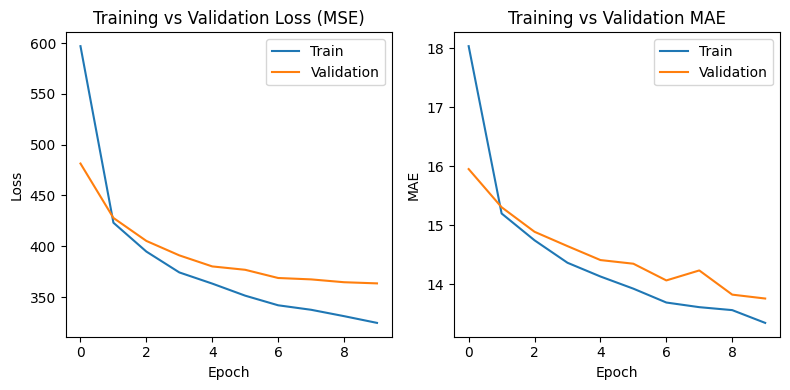

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Training vs Validation Loss (MSE)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train')
plt.plot(history.history['val_mae'], label='Validation')
plt.title("Training vs Validation MAE")
plt.xlabel("Epoch"); plt.ylabel("MAE"); plt.legend()
plt.tight_layout()
plt.show()

8. Evaluasi Model

MAE  = 13.76
RMSE = 19.07
R²   = 0.178


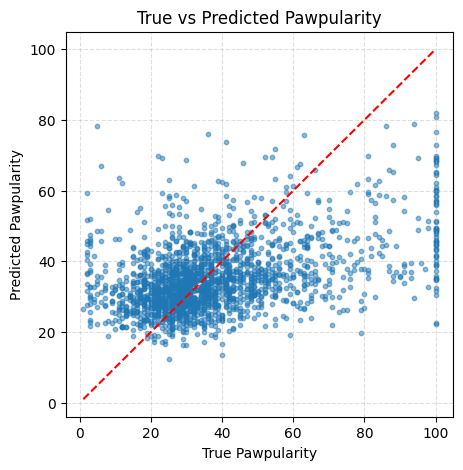

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from math import sqrt

y_true = val_df['Pawpularity'].values.astype(np.float32)
y_pred = np.concatenate([model.predict(batch[0], verbose=0).ravel() for
batch in val_ds])

mae = mean_absolute_error(y_true, y_pred)
rmse = sqrt(np.mean((y_true - y_pred)**2))
r2 = r2_score(y_true, y_pred)
print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R²   = {r2:.3f}")

# Plot hasil prediksi vs nilai sebenarnya:
plt.figure(figsize=(5,5))
plt.scatter(y_true, y_pred, s=10, alpha=0.5)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, '--', color='red')
plt.xlabel("True Pawpularity")
plt.ylabel("Predicted Pawpularity")
plt.title("True vs Predicted Pawpularity")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

9. Melihat Contoh Prediksi

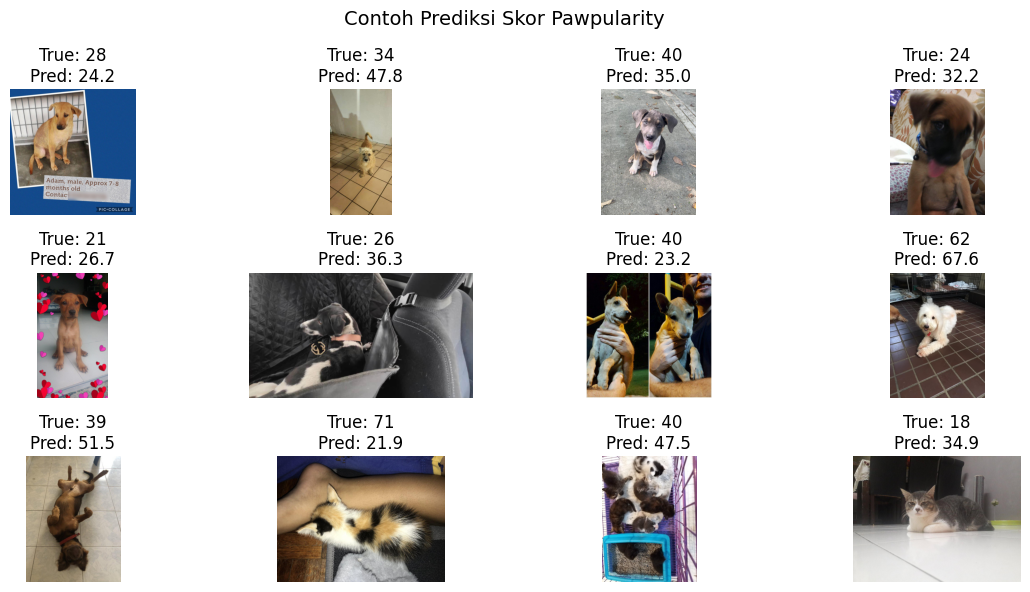

In [ ]:
import random
from PIL import Image

sample_rows = val_df.sample(12, random_state=1)

plt.figure(figsize=(12,6))
for i, row in enumerate(sample_rows.itertuples()):
  img = Image.open(row.path)
  pred = model.predict(tf.expand_dims(load_image(row.path, row.Pawpularity)[0], 0), verbose=0).ravel()[0]
  plt.subplot(3,4,i+1)
  plt.imshow(img)
  plt.title(f"True: {row.Pawpularity}\nPred: {pred:.1f}")
  plt.axis('off')
plt.suptitle("Contoh Prediksi Skor Pawpularity", fontsize=14)
plt.tight_layout()
plt.show()

10. Tantangan Mini

In [ ]:
# 1: Data Augmentation

def load_image_aug(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    # Tambahkan Augmentasi Acak
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.2)

    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.cast(label, tf.float32)

train_ds_aug = tf.data.Dataset.from_tensor_slices((train_df['path'], train_df['Pawpularity']))\
    .map(load_image_aug, num_parallel_calls=tf.data.AUTOTUNE)\
    .shuffle(4096).batch(64).prefetch(tf.data.AUTOTUNE)

print("Dataset dengan augmentasi siap! Coba latih ulang modelmu menggunakan `train_ds_aug` dan lihat apakah val_loss-nya jadi lebih baik.")

Dataset dengan augmentasi siap! Coba latih ulang modelmu menggunakan `train_ds_aug` dan lihat apakah val_loss-nya jadi lebih baik.


In [ ]:
# 2: Menggunakan RestNet50

base_resnet = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights='imagenet'
)
base_resnet.trainable = False

inputs = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3))
x = base_resnet(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(1)(x)

model_resnet = tf.keras.Model(inputs, outputs)
model_resnet.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_resnet.summary()

print("Model ResNet50 siap! Silakan jalankan `model_resnet.fit(...)` menggunakan datasetmu untuk membandingkan performanya dengan EfficientNet.")

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Model ResNet50 siap! Silakan jalankan `model_resnet.fit(...)` menggunakan datasetmu untuk membandingkan performanya dengan EfficientNet.


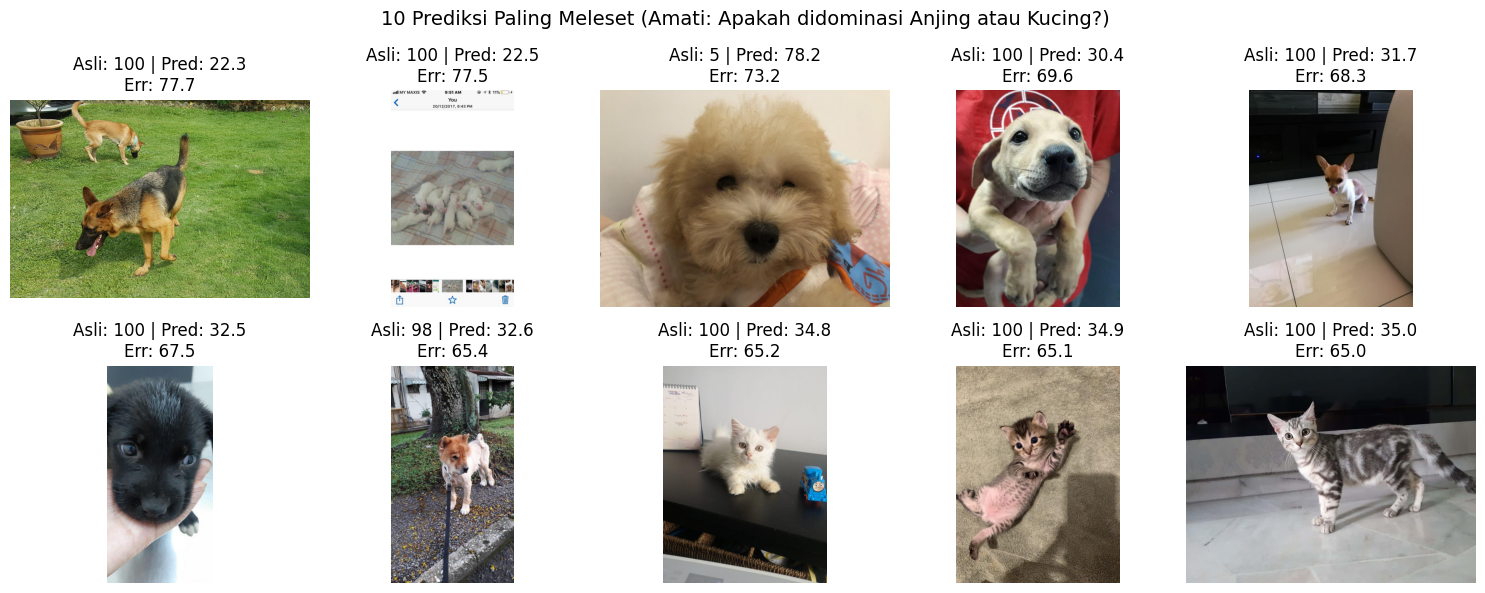

In [ ]:
# 3: Eksprerimen

# Hitung selisih antara tebakan model dan nilai asli
val_df['Prediksi'] = y_pred
val_df['Error'] = abs(val_df['Pawpularity'] - val_df['Prediksi'])

# Ambil 10 gambar dengan Error paling besar
worst_preds = val_df.sort_values('Error', ascending=False).head(10)

plt.figure(figsize=(15,6))
for i, row in enumerate(worst_preds.itertuples()):
    img = Image.open(row.path)
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(f"Asli: {row.Pawpularity} | Pred: {row.Prediksi:.1f}\nErr: {row.Error:.1f}")
    plt.axis('off')

plt.suptitle("10 Prediksi Paling Meleset (Amati: Apakah didominasi Anjing atau Kucing?)", fontsize=14)
plt.tight_layout()
plt.show()

Menghitung rata-rata brightness untuk data validasi (mungkin butuh waktu beberapa detik)...
Korelasi Kecerahan vs Kepopuleran: 0.039


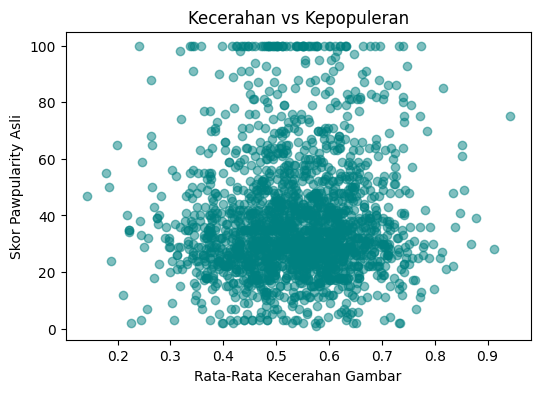

In [ ]:
# 4: Fitur Non-Visual

import cv2

def get_brightness(image_path):
    img = cv2.imread(image_path)
    # Ubah format warna ke HSV dan ambil channel 'V' (Value/Brightness)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    return img_hsv[:,:,2].mean() / 255.0

print("Menghitung rata-rata brightness untuk data validasi (mungkin butuh waktu beberapa detik)...")
val_df['Brightness'] = val_df['path'].apply(get_brightness)

# Cek korelasi linear
korelasi = val_df['Brightness'].corr(val_df['Pawpularity'])
print(f"Korelasi Kecerahan vs Kepopuleran: {korelasi:.3f}")

# Visualisasikan
plt.figure(figsize=(6,4))
plt.scatter(val_df['Brightness'], val_df['Pawpularity'], alpha=0.5, color='teal')
plt.xlabel("Rata-Rata Kecerahan Gambar")
plt.ylabel("Skor Pawpularity Asli")
plt.title("Kecerahan vs Kepopuleran")
plt.show()

Penugasan

Silakan upload foto hewan peliharaanmu (format jpg/jpeg/png):


Saving download (5).jfif to download (5) (2).jfif


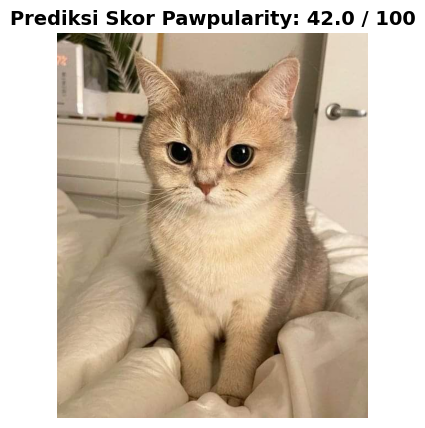

In [ ]:
from google.colab import files
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt

print("Silakan upload foto hewan peliharaanmu (format jpg/jpeg/png):")
uploaded = files.upload()

IMG_SIZE = 224

for fn in uploaded.keys():
    path = '/content/' + fn

    # Pre-processing gambar sesuai dengan model Pawpularity
    img_tensor = tf.io.read_file(path)
    img_tensor = tf.image.decode_jpeg(img_tensor, channels=3)
    img_tensor = tf.image.resize(img_tensor, (IMG_SIZE, IMG_SIZE))
    img_tensor = tf.cast(img_tensor, tf.float32) / 255.0

    # Prediksi menggunakan model D3
    pred_pawpularity = model.predict(tf.expand_dims(img_tensor, 0), verbose=0).ravel()[0]

    # Tampilkan hasil
    plt.figure(figsize=(5,5))
    img_show = Image.open(path)
    plt.imshow(img_show)
    plt.title(f"Prediksi Skor Pawpularity: {pred_pawpularity:.1f} / 100", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()